# 07. 관세청 수입량 — 붙일 값어치가 있는가

06번에서 외부 데이터 **1순위로 관세청 수입량**을 꼽았다. 근거는:

- 예측 기울기 최하위가 **감자(0.068) · 양파(0.093)** 인데 둘 다 **저장 작물**이다.
  수확 후 저장했다가 연중 출하하므로 그날의 기상·출하량보다 재고와 수입에 좌우된다.
- 오차가 가장 큰 달이 **5월** — 햇양파 출하 전환기다.
- 마트에 재고·수입 축이 **통째로 비어 있다**.

활용신청이 승인됐으니 여기서 실제로 받아 **붙일 값어치가 있는지 판정**한다.
상관만 보고 결정하지 않는다 — 06번에서 기상 극단이 그럴듯했는데도 모델에
넣으니 오히려 해로웠다(+0.075). 마지막에 ablation 으로 확인한다.

In [1]:
import re
import time
from pathlib import Path
from urllib.parse import unquote

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingRegressor

from extract.clients.base_client import BaseClient
from extract.config import settings

_available = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _available:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
CACHE = ROOT / "notebooks" / ".cache"

df = pd.read_parquet(CACHE / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
items = sorted(df.item.unique())
print(f"마트 {len(df):,}행 | {df.price_date.max():%Y-%m-%d}")

마트 8,220행 | 2026-08-06


## 1. API 제약과 품목 매핑

### 확인된 제약 (실측)

| 항목 | 내용 |
|---|---|
| 엔드포인트 | `apis.data.go.kr/1220000/Itemtrade/getItemtradeList` |
| 인증 | **기존 data.go.kr 키 공용**. 활용신청만 따로 |
| **조회기간** | **1년 이내**. 넘으면 `resultCode 99` — KAMIS 와 같은 제약이라 연 단위로 끊는다 |
| 응답 | XML. `<item>` 안에 `hsCode` · `statKor` · `year`(YYYY.MM) · `impWgt` · `impDlr` 등 |
| **총계 행** | 마지막에 `year=총계` 행이 섞인다. **반드시 걸러야 한다** |
| `hsSgn` 자릿수 | **4자리를 넣으면 하위 10자리 세번을 한꺼번에 준다** |

마지막 항목 덕분에 매핑 비용이 예상보다 훨씬 작았다. 4자리로 훑어 `statKor`
(한글 품목명)을 보고 고르면 되기 때문에, 10자리 세번을 사람이 대조할 필요가 없다.

### 품목 매핑 (2026-01 실측 수입량으로 확인)

| 품목 | HS 세번 | 2026-01 수입 | 비고 |
|---|---|---|---|
| 양파 | 0703101010 + 0703101090 | **9,374톤** | 압도적 |
| 감자 | 0701900000 | 2,436톤 | '기타' = 종자용 제외 신선 |
| 파 | 0703902000 | 1,031톤 | 세번명이 그대로 '대파' |
| 배추 | 0704902000 | 524톤 | **06번 추정이 틀렸다** — 신선 배추도 들어온다 |
| 생강 | 0910111000 | 171톤 | 양파의 1/55. 06번에서 과대평가했다 |
| **미나리** | **없음** | — | **독립 세번이 없다.** 0709999000 '기타'에 섞여 추적 불가 |

미나리는 이 데이터로 다룰 수 없다. 다만 미나리는 예측 기울기가 가장 높아
(0.179) 이미 상대적으로 잘 되는 품목이라 손실은 크지 않다.

In [2]:
URL = "https://apis.data.go.kr/1220000/Itemtrade/getItemtradeList"
HS = {"양파": ["0703101010", "0703101090"], "감자": ["0701900000"],
      "파": ["0703902000"], "배추": ["0704902000"], "생강": ["0910111000"]}
IMP_CACHE = CACHE / "customs_import.parquet"


def fetch_year(client, key, hs, yr):
    """한 세번의 1년치. 조회기간 1년 제한 때문에 연 단위로 끊는다."""
    r = client.session.get(URL, params={"serviceKey": key, "strtYymm": f"{yr}01",
                                        "endYymm": f"{yr}12", "hsSgn": hs}, timeout=30)
    out = []
    for it in re.findall(r"<item>(.*?)</item>", r.text, re.S):
        d = dict(re.findall(r"<(\w+)>([^<]*)</\1>", it))
        y = d.get("year", "")
        # year 가 'YYYY.MM' 인 행만. '총계' 행을 넣으면 그 해가 두 번 세어진다.
        if d.get("hsCode") == hs and re.match(r"^\d{4}\.\d{2}$", y):
            out.append({"ym": y.replace(".", "-"),
                        "imp_kg": float(d.get("impWgt") or 0),
                        "imp_usd": float(d.get("impDlr") or 0)})
    return out


def load_imports(refresh=False):
    if IMP_CACHE.exists() and not refresh:
        cached = pd.read_parquet(IMP_CACHE)
        if {"item", "ym", "imp_kg"}.issubset(cached.columns):
            return cached
    client = BaseClient()
    key = unquote(settings.DATAGO_SERVICE_KEY)   # 관세청도 같은 포털 키
    rows = []
    for item, codes in HS.items():
        for code in codes:
            for yr in range(2021, 2027):
                rows += [{"item": item, **x} for x in fetch_year(client, key, code, yr)]
    imp = pd.DataFrame(rows).groupby(["item", "ym"], as_index=False)[["imp_kg", "imp_usd"]].sum()
    imp.to_parquet(IMP_CACHE, index=False)
    return imp


imp = load_imports()
imp["ym"] = pd.PeriodIndex(imp.ym, freq="M")
print(f"수입 {len(imp)}행 | {imp.ym.min()} ~ {imp.ym.max()} | 품목 {imp.item.nunique()}개")
display(imp.groupby("item").imp_kg.agg(["count", "mean", "min", "max"]).round(0))

수입 306행 | 2021-01 ~ 2026-06 | 품목 5개


,count,mean,min,max
item,,,,
감자,66,3365304.0,0.0,9784601.0
배추,66,437747.0,0.0,4830413.0
생강,66,376586.0,8150.0,2110690.0
양파,54,8431127.0,3000.0,21340700.0
파,54,941214.0,0.0,4339720.0


## 2. 역인과 — 이 데이터의 핵심 함정

수입량과 가격의 **동시점 상관은 양수**로 나온다. 그런데 공급이 늘면 가격은
내려야 한다. 부호가 반대라는 건 인과의 방향이 반대라는 뜻이다.

> **가격이 오르니까 수입을 늘린 것**이지, 수입이 가격을 올린 게 아니다.

수입업자는 국내 시세를 보고 발주한다. 그래서 동시점 수입량은 **가격의 결과**다.
이걸 피처로 넣으면 모델이 "수입이 많으면 비싸다"를 배우는데, 예측 시점에는
그 달 수입량을 알 수도 없다.

**써도 되는 건 시차를 준 값뿐이다.** 실제로 공급 효과가 있다면 수입이 들어오고
한두 달 뒤 가격이 눌려야 하므로, **시차 상관은 음수**로 나와야 한다.
아래에서 그 구조를 확인한다.

,n,수준,동시점변화,1개월선행,2개월선행,3개월선행,4개월선행,6개월선행
item,,,,,,,,
감자,66,0.585,0.160,0.364,-0.062,-0.275,0.052,-0.276
배추,66,0.641,0.551,0.036,-0.383,-0.271,-0.033,-0.060
생강,66,0.006,0.006,-0.043,-0.160,-0.216,0.120,-0.102
양파,54,0.558,0.556,0.091,-0.186,-0.247,-0.044,0.220
파,54,0.359,0.403,-0.314,-0.059,-0.179,-0.141,0.199


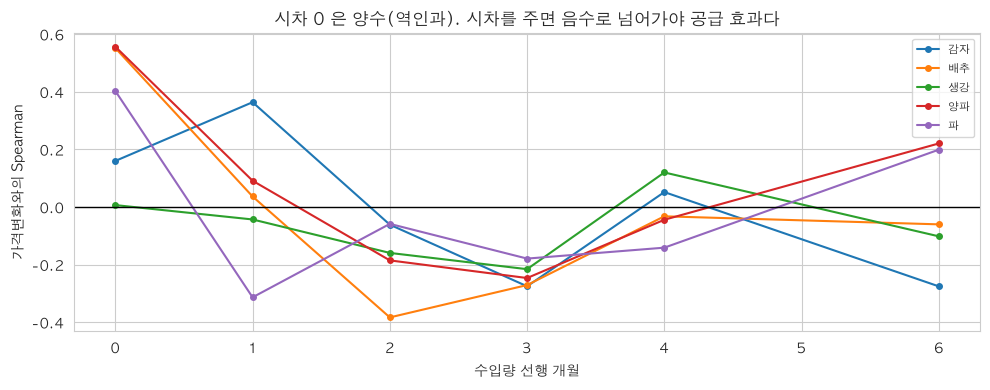

In [3]:
d = df.copy()
d["ym"] = pd.PeriodIndex(d.price_date, freq="M")
price = d.groupby(["item", "ym"], as_index=False).price_kg_avg.mean()
m = price.merge(imp, on=["item", "ym"], how="inner").sort_values(["item", "ym"])

rows = []
for it, g in m.groupby("item"):
    dp = np.log(g.price_kg_avg).diff()
    di = np.log(g.imp_kg.replace(0, np.nan)).diff()
    rec = {"item": it, "n": len(g),
           "수준": g.price_kg_avg.corr(g.imp_kg, method="spearman"),
           "동시점변화": dp.corr(di, method="spearman")}
    for k in (1, 2, 3, 4, 6):
        rec[f"{k}개월선행"] = dp.corr(di.shift(k), method="spearman")
    rows.append(rec)
display(pd.DataFrame(rows).set_index("item").round(3))

lags = [0, 1, 2, 3, 4, 6]
fig, ax = plt.subplots(figsize=(10, 4))
for it, g in m.groupby("item"):
    dp = np.log(g.price_kg_avg).diff()
    di = np.log(g.imp_kg.replace(0, np.nan)).diff()
    ax.plot(lags, [dp.corr(di.shift(k), method="spearman") for k in lags],
            marker="o", ms=4, label=it)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("수입량 선행 개월"); ax.set_ylabel("가격변화와의 Spearman")
ax.set_title("시차 0 은 양수(역인과). 시차를 주면 음수로 넘어가야 공급 효과다")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. 모델에 넣는 법 — 발표 지연을 반영한다

관세청 통계는 **그 달이 끝난 뒤 익월에 확정 발표**된다. 즉 `t` 시점(예: 3월 10일)에
실제로 알 수 있는 건 **1월분까지**로 봐야 안전하다. 2월분은 아직 집계 중일 수 있다.

그래서 **2개월 전 수입량**을 기준으로 피처를 만든다. 이건 보수적인 선택이고,
역인과 문제도 같이 피해 간다.

만드는 피처 (전부 2개월 시차):

| 피처 | 뜻 |
|---|---|
| `imp_log` | 2개월 전 수입량(로그). 수준 |
| `imp_chg` | 그 달의 전월 대비 증감 |
| `imp_yoy` | 전년 동월 대비. 계절을 제거한 물량 국면 |
| `imp_dev12` | 최근 12개월 평균 대비 편차 |

**미나리는 값이 없어 NaN 이다.** 트리 모델은 결측을 그대로 처리하므로 별도
대치를 하지 않는다 — 0 으로 채우면 "수입이 0 인 달"과 구분되지 않는다.

기준선은 **06번 채택안**(기본 36 + `seasonal_pos` 3)이다. 06번에서 유일하게
뚜렷하게 값을 한 그룹이라 그 위에서 수입 피처의 순수 기여를 본다.

In [4]:
imp2 = imp.sort_values(["item", "ym"]).copy()
imp2["_log"] = np.log(imp2.imp_kg.replace(0, np.nan))
g = imp2.groupby("item")
imp2["imp_log"] = g._log.shift(2)
imp2["imp_chg"] = g._log.diff().shift(2)
imp2["imp_yoy"] = (imp2._log - g._log.shift(12)).shift(2)
imp2["imp_dev12"] = (imp2._log - g._log.transform(
    lambda s: s.rolling(12, min_periods=6).mean())).shift(2)
CUSTOMS = ["imp_log", "imp_chg", "imp_yoy", "imp_dev12"]

# 월값을 그 달의 모든 거래일에 붙인다
base = df.copy()
base["ym"] = pd.PeriodIndex(base.price_date, freq="M")
base = base.merge(imp2[["item", "ym"] + CUSTOMS], on=["item", "ym"], how="left")

print("품목별 수입 피처 결측률(%) — 미나리는 100% 가 정상")
display((base.groupby("item")[CUSTOMS].apply(lambda x: x.isna().mean() * 100)).round(1))

품목별 수입 피처 결측률(%) — 미나리는 100% 가 정상


,imp_log,imp_chg,imp_yoy,imp_dev12
item,,,,
감자,12.0,17.9,31.6,19.8
미나리,100.0,100.0,100.0,100.0
배추,40.8,51.3,67.6,57.4
생강,4.7,3.5,20.0,9.7
양파,22.9,21.6,38.2,27.7
파,28.9,30.6,44.3,33.6


In [5]:
H = 7
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
EMBARGO = pd.Timedelta(days=int(H * 1.5))
TUNED = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
             max_leaf_nodes=15, l2_regularization=1.0)
BASE_EXO = ["temp_avg", "temp_min", "temp_max", "precip_mm_avg", "precip_mm_max",
            "humidity_avg", "sunshine_hr_avg", "shipment_qty", "shipment_qty_w1ago"]
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]


def build(src, h=H):
    d = src.copy()
    d["_logp"] = np.log(d.price_kg_avg)

    def gg(col):
        return d.groupby("item")[col]

    d["y"] = gg("_logp").shift(-h) - d._logp
    for lag in (1, 2, 3, 5, 10, 20):
        d[f"ret{lag}"] = d._logp - gg("_logp").shift(lag)
    for w in (5, 20, 60):
        mp = max(2, w // 3)
        d[f"dev{w}"] = d._logp - gg("_logp").transform(
            lambda s: s.rolling(w, min_periods=mp).mean())
        d[f"vol{w}"] = gg("_logp").transform(
            lambda s: s.diff().rolling(w, min_periods=mp).std())
    for c in BASE_EXO:
        d[f"{c}_l1"] = gg(c).shift(1)
        d[f"{c}_d20"] = d[f"{c}_l1"] - gg(c).transform(
            lambda s: s.shift(1).rolling(20, min_periods=7).mean())
    doy = d.price_date.dt.dayofyear
    d["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    d["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    d["seas_dev"] = d._logp - (d.groupby(["item", "month"])["_logp"]
                               .transform(lambda s: s.shift(1).expanding(min_periods=20).mean()))
    d["item_code"] = pd.Categorical(d.item, categories=items).codes
    return d


BASE_FEATS = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)]
              + [f"dev{w}" for w in (5, 20, 60)] + [f"vol{w}" for w in (5, 20, 60)]
              + [f"{c}_l1" for c in BASE_EXO] + [f"{c}_d20" for c in BASE_EXO]
              + CAL + ["doy_sin", "doy_cos", "seas_dev", "item_code"])

full = build(base).dropna(subset=["y"]).reset_index(drop=True)


def run(feats):
    cat = [feats.index(c) for c in ("item_code", "month", "dayofweek")]
    out = []
    for s, e in FOLDS:
        s, e = pd.Timestamp(s), pd.Timestamp(e)
        tr = full[full.price_date < s - EMBARGO]
        te = full[(full.price_date >= s) & (full.price_date <= e)]
        mdl = HistGradientBoostingRegressor(
            loss="absolute_error", categorical_features=cat, early_stopping=False,
            random_state=42, **TUNED).fit(tr[feats], tr.y)
        t = te[["item", "y"]].copy()
        t["pred"] = mdl.predict(te[feats])
        out.append(t)
    r = pd.concat(out)
    r["ape"] = np.abs(np.exp(r.pred) - np.exp(r.y)) / np.exp(r.y) * 100
    per = r.groupby("item").ape.mean()
    return per, per.mean(), np.polyfit(r.y, r.pred, 1)[0]


t0 = time.time()
res = {}
for name, feats in (("기준(06번 채택)", BASE_FEATS),
                    ("+수입", BASE_FEATS + CUSTOMS)):
    res[name] = run(feats)
    print(f"{name:16} MAPE {res[name][1]:.3f}  기울기 {res[name][2]:.3f}"
          f"  ({time.time()-t0:.0f}초)")

cmp = pd.DataFrame({k: v[0] for k, v in res.items()})
cmp["차이"] = cmp["+수입"] - cmp["기준(06번 채택)"]
cmp.loc["— 전체 —"] = [res["기준(06번 채택)"][1], res["+수입"][1],
                     res["+수입"][1] - res["기준(06번 채택)"][1]]
display(cmp.round(3))

기준(06번 채택)       MAPE 8.120  기울기 0.155  (14초)


+수입              MAPE 8.192  기울기 0.154  (29초)


,기준(06번 채택),+수입,차이
item,,,
감자,7.157,7.356,0.199
미나리,10.498,10.304,-0.194
배추,12.257,12.504,0.247
생강,2.705,2.834,0.129
양파,5.564,5.545,-0.019
파,10.536,10.611,0.075
— 전체 —,8.120,8.192,0.073


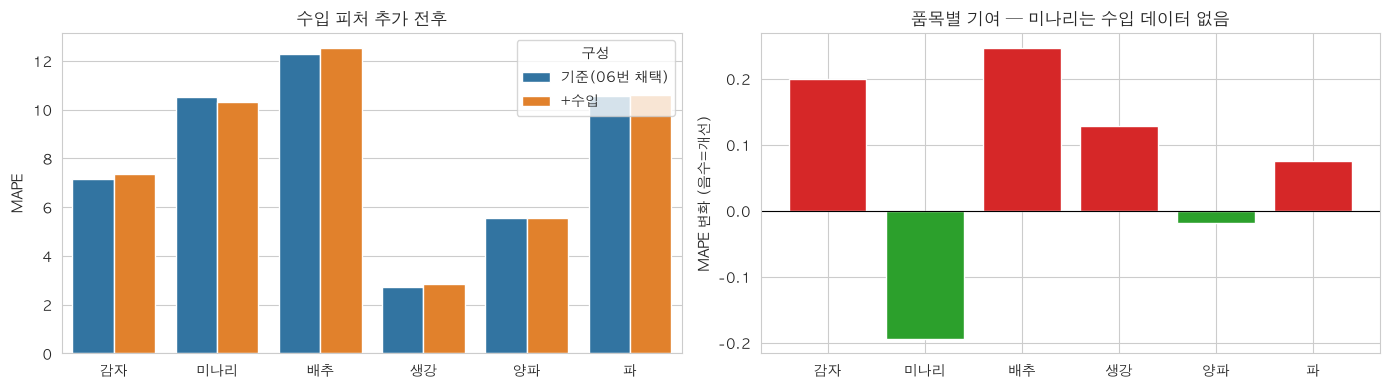

In [6]:
plot = (cmp.drop(index="— 전체 —").drop(columns="차이")
        .rename_axis("item").reset_index()
        .melt(id_vars="item", var_name="구성", value_name="MAPE"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=plot, x="item", y="MAPE", hue="구성", ax=axes[0])
axes[0].set_title("수입 피처 추가 전후"); axes[0].set_xlabel("")

delta = cmp.drop(index="— 전체 —")["차이"]
axes[1].bar(delta.index, delta.values,
            color=["tab:green" if v < 0 else "tab:red" for v in delta])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_ylabel("MAPE 변화 (음수=개선)")
axes[1].set_title("품목별 기여 — 미나리는 수입 데이터 없음")
plt.tight_layout()
plt.show()

## 4. 정리

### 결과 — 수입 피처는 값을 하지 않는다

| 품목 | 기준(06번 채택) | +수입 | 차이 |
|---|---|---|---|
| 감자 | 7.157 | 7.356 | **+0.199** |
| 배추 | 12.257 | 12.504 | **+0.247** |
| 생강 | 2.705 | 2.834 | +0.129 |
| 파 | 10.536 | 10.611 | +0.075 |
| 양파 | 5.564 | 5.545 | -0.019 |
| **미나리** | 10.498 | 10.304 | **-0.194** |
| **전체** | **8.120** | **8.192** | **+0.073** |

기울기도 0.155 → 0.154 로 그대로다. **변화를 더 잡게 되지도 않았다.**

### 미나리가 노이즈 플로어를 알려준다 — 이 노트북에서 가장 쓸모 있는 발견

**미나리는 수입 피처가 100% 결측인데도 -0.194 만큼 좋아졌다.** 입력이 하나도
안 바뀐 품목의 성능이 그만큼 움직였다는 뜻이다. 다른 품목의 데이터가 바뀌면서
트리 분기가 통째로 달라진 결과다.

그러면 **±0.2 안쪽의 변화는 신호로 읽으면 안 된다.** 감자 +0.199, 배추 +0.247,
전체 +0.073 이 전부 이 범위 언저리다. 즉 정확한 표현은 "수입 피처가 해롭다"가
아니라 **"값을 하지 않는다"** 이다.

이 기준은 앞으로 ablation 을 읽을 때도 써야 한다. 06번에서 `seasonal_pos` 가
-0.053 이었는데, 그 크기만으로는 잡음과 구분되지 않는다. 다만 그때는 **기울기가
0.123 → 0.155 로 함께 올라서** 방향이 맞다는 별도 근거가 있었다. 여기서는
기울기가 움직이지 않았다.

### 왜 안 됐나

**1. 역인과 구조.** 동시점 상관은 양수(배추 0.551, 양파 0.556)인데 이건 "가격이
올라서 수입을 늘린" 것이다. 쓸 수 있는 시차 상관은 훨씬 약하다(2개월 -0.186 ~
-0.383). 그마저 3개월·4개월에서 부호가 오락가락해 안정적인 구조가 아니다.

**2. 결측이 많다.** 수입이 0 인 달이 흔해서 로그를 취하면 NaN 이 된다.
`imp_yoy` 기준 배추 67.6% · 파 44.3% · 양파 38.2% 가 결측이다. 피처가 있는
날보다 없는 날이 많은 경우도 있다.

**3. 주기가 안 맞는다.** 월 단위 데이터에 발표 지연 2개월을 더하면, 7거래일
앞을 맞히는 문제에는 너무 저주파다. "지금은 수입이 많은 국면" 정도의 정보인데
그건 이미 `seas_dev`·`month` 가 어느 정도 담고 있다.

### 06번의 추정 중 틀린 것

- "배추는 신선 상태로 거의 안 들어온다" → **틀렸다.** 월 524톤 들어온다.
- "생강은 중국산이 많다" → **과대평가.** 신선 생강은 양파의 1/55 다.
- "미나리는 수입이 없다" → 맞지만, **독립 세번 자체가 없어** 추적이 불가능하다.

도메인 논리(저장 작물이니 수입이 중요할 것)는 그럴듯했지만 **실제로 재보니
값을 하지 않았다.** 06번에서 기상 극단이 같은 식으로 실패한 것과 같은 패턴이다.

### 그래도 남는 것

수집 코드와 매핑은 검증됐다. 나중에 **월 단위 예측**이나 **가격 수준(level)
모델**을 한다면 그때는 유효할 수 있다. 7거래일 변화율 예측에 안 맞을 뿐이다.

API 제약(1년 조회 한도, 총계 행, 4자리 hsSgn)도 1절에 정리해뒀으니, 파이프라인
으로 승격할 일이 생기면 그대로 쓰면 된다.

### 다음

1. **수입 피처는 채택하지 않는다.** 기본 + `seasonal_pos` 구성을 유지한다.
2. 06번 5절의 남은 후보 중 **KOSIS 재배면적**은 연 단위라 같은 이유로 더
   불리할 가능성이 크다. **저장 물량**이 그나마 주기가 맞을 수 있으나 공개
   API 를 아직 확인하지 못했다.
3. 데이터를 더 찾기보다 **품목 수를 늘려 표본을 키우는 쪽**이 남은 선택지다.
   지금 6품목 × 1,371일로는 어떤 피처를 넣어도 잡음이 ±0.2 라 검증이 안 된다.
